# Retail Sales Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover customer purchasing behavior, sales trends, product performance, and business insights using Python.

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

### Dataset

Retail Sales Dataset

---

### Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Business Insights
8. Recommendations


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [37]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

df.info()

Dataset shape: (1000, 9)

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), 

## Data Cleaning and Feature Engineering

In [38]:
# Ensure the Date column is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Remove duplicate rows, if any
df = df.drop_duplicates()

# Create useful columns for analysis
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

# Group customers by age
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (1000, 13)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month_Name,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,26-35


## Univariate Analysis

### Age Distribution

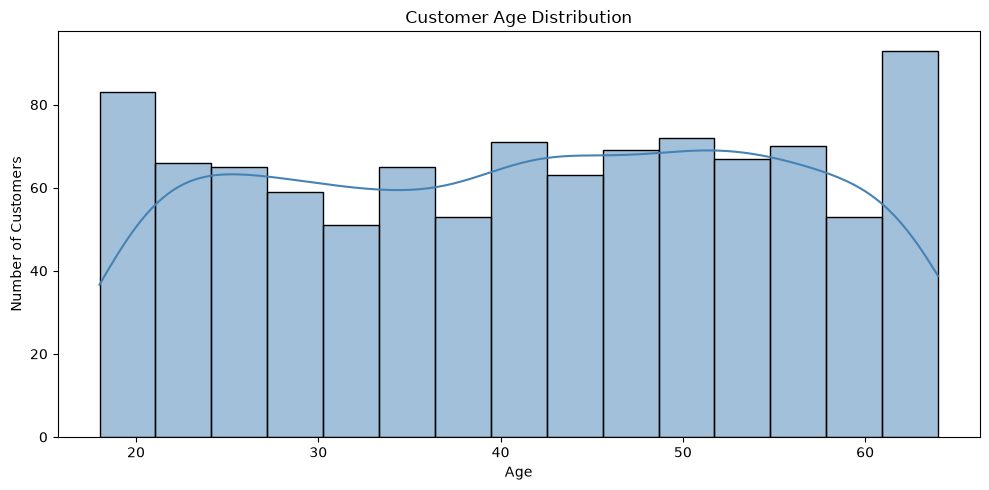

In [39]:
from pathlib import Path

# Create a folder to save chart images
Path("Images").mkdir(exist_ok=True)

# Create the age distribution chart
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", bins=15, kde=True, color="steelblue")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()

# Save the image for GitHub/project submission
plt.savefig("Images/age_distribution.png", dpi=300)
plt.show()

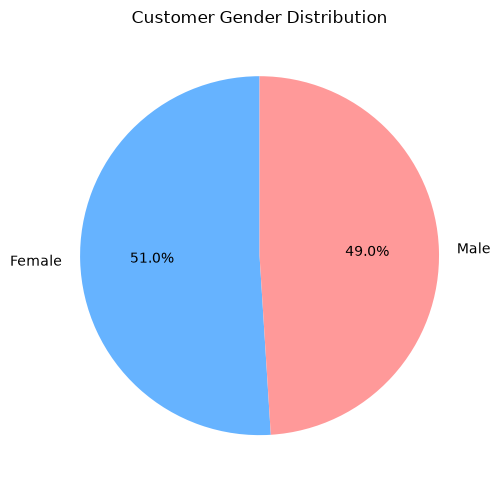

In [40]:
# Gender distribution chart
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"]
)

plt.title("Customer Gender Distribution")
plt.tight_layout()

plt.savefig("Images/gender_distribution.png", dpi=300)
plt.show()

In [41]:
# Convert Date column to proper date format
df["Date"] = pd.to_datetime(df["Date"])

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Create useful time columns for analysis
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df.head()

Duplicate rows: 0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month_Name,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,26-35


## Product Category Analysis

### Total Sales by Product Category

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


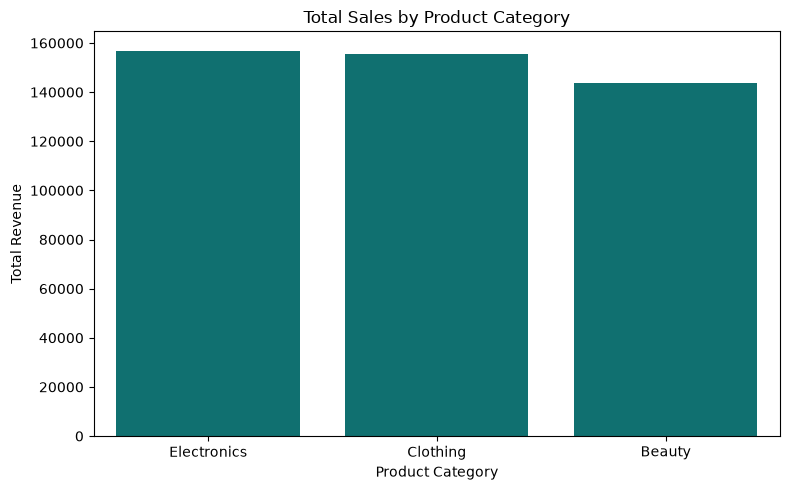

In [42]:
# Calculate total revenue for each product category
category_sales = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

# Create category sales chart
plt.figure(figsize=(8, 5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    color="teal"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.savefig("Images/category_sales.png", dpi=300)
plt.show()

## Time Series Analysis

### Monthly Sales Trend

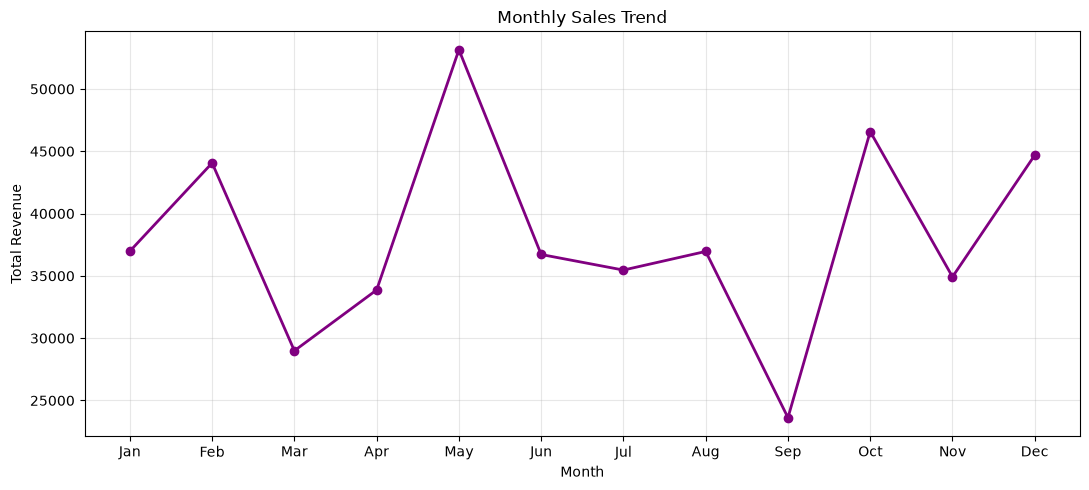

In [43]:
# Calculate total sales for each month in calendar order
monthly_sales = (
    df.groupby("Month")["Total Amount"]
    .sum()
    .reindex(range(1, 13), fill_value=0)
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Create the monthly sales trend chart
plt.figure(figsize=(11, 5))
plt.plot(
    month_labels,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color="purple"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Images/sales_trend.png", dpi=300)
plt.show()

## Correlation Analysis

### Relationship Between Numerical Variables

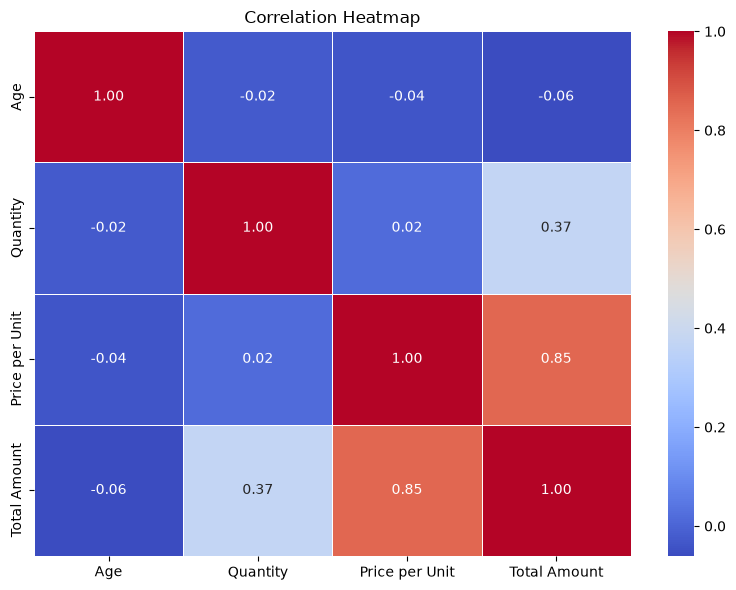

In [44]:
# Select meaningful numerical columns for correlation
numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]

# Calculate correlations
correlation_matrix = df[numeric_columns].corr()

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("Images/heatmap.png", dpi=300)
plt.show()

## Bivariate Analysis

### Revenue by Gender

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


C:\Users\madha\AppData\Local\Temp\ipykernel_17012\2728819177.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


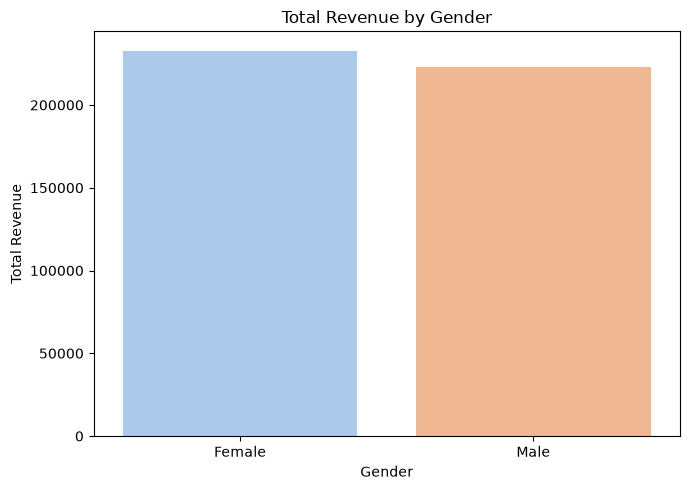

In [45]:
# Calculate total revenue by gender
gender_sales = (
    df.groupby("Gender")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(gender_sales)

# Create revenue-by-gender chart
plt.figure(figsize=(7, 5))
sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values,
    palette="pastel"
)

plt.title("Total Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.savefig("Images/revenue_by_gender.png", dpi=300)
plt.show()

### Revenue by Customer Age Group

Age_Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56+       80410
Name: Total Amount, dtype: int64


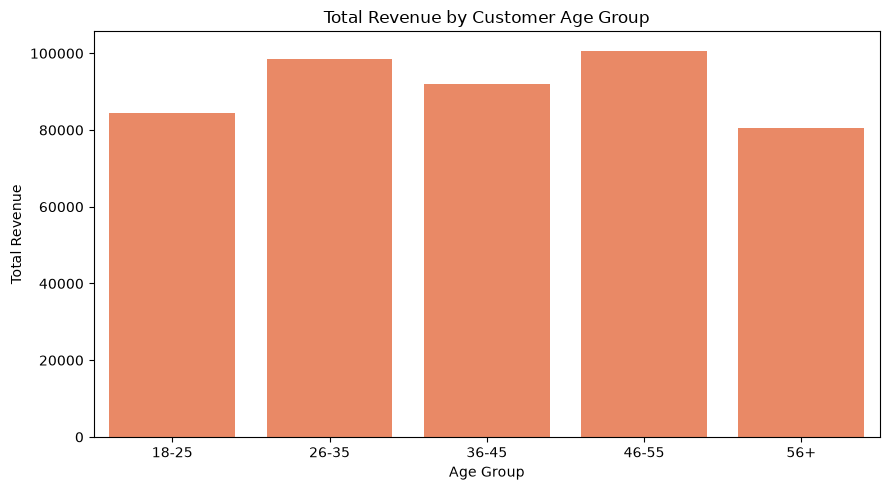

In [46]:
# Calculate total revenue by age group
age_group_sales = (
    df.groupby("Age_Group", observed=False)["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(age_group_sales)

# Create revenue-by-age-group chart
plt.figure(figsize=(9, 5))
sns.barplot(
    x=age_group_sales.index,
    y=age_group_sales.values,
    color="coral"
)

plt.title("Total Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.savefig("Images/age_group_sales.png", dpi=300)
plt.show()

## Business Insights

- The dataset contains 1,000 transactions and has no missing values or duplicate records.
- Electronics is the highest-revenue product category, followed closely by Clothing.
- May recorded the highest monthly sales, while September recorded the lowest.
- Female customers generated slightly more revenue than male customers.
- Customers aged 46–55 contributed the highest revenue; the 26–35 group was the next strongest.
- Price per Unit has a strong positive relationship with Total Amount (correlation: 0.85).
- Quantity has a moderate positive relationship with Total Amount (correlation: 0.37).
- Customer age has almost no direct correlation with Total Amount.

## Business Recommendations

- Maintain strong inventory availability for Electronics because it generates the highest revenue.
- Run targeted promotions for customers aged 46–55 and 26–35, the two strongest revenue-contributing groups.
- Prepare higher inventory and marketing campaigns before May, the peak sales month.
- Investigate the low sales recorded in September and introduce discounts or seasonal campaigns during that period.
- Use product bundles and premium offers because unit price has the strongest relationship with total revenue.
- Continue engaging female customers while designing inclusive campaigns for both genders.

## Conclusion

This analysis examined 1,000 retail transactions to understand customer behavior, category performance, and sales trends. Electronics generated the highest revenue, May was the strongest sales month, and customers aged 46–55 were the most valuable customer group. These findings can help the business improve inventory planning, marketing campaigns, and customer targeting.

# Create an Output folder and save the cleaned dataset
Path("Output").mkdir(exist_ok=True)

df.to_csv("Output/cleaned_retail_sales.csv", index=False)

print("Cleaned dataset saved successfully: Output/cleaned_retail_sales.csv")

In [47]:
Path("Output").mkdir(exist_ok=True)

df.to_csv("Output/cleaned_retail_sales.csv", index=False)

print("Cleaned dataset saved successfully: Output/cleaned_retail_sales.csv")

Cleaned dataset saved successfully: Output/cleaned_retail_sales.csv
